### OVERALL MODEL SUMMARY    
The performance metrics and feature importance from the various classifiers are summarized.

**Import the required libraries**

In [ ]:
!pip install groq
from groq import Groq
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 11.1 MB/s eta 0:00:00


##Overall Performance Metrics

Load the **performance metrics** of the different classifiers.

In [ ]:
# Load the Decision Tree metrics
dtree_model_df = pd.read_csv('dtree_model.csv')

print(dtree_model_df.head())

      Classifier    AUC  Accuracy  Precision    Recall  F2 Score  Profit/Loss
0  Decision Tree  0.929  0.974833   0.238095  0.865385  0.566751        22840


In [ ]:
# Rename 'Model' column
dtree_model_df = dtree_model_df.rename(columns={'Classifier': 'Model'})

print(dtree_model_df.head())

           Model    AUC  Accuracy  Precision    Recall  F2 Score  Profit/Loss
0  Decision Tree  0.929  0.974833   0.238095  0.865385  0.566751        22840


In [ ]:
# Load the Random Forest metrics
rf_model_df = pd.read_csv('rf_model.csv')

print(rf_model_df.head())

      Classifier    AUC  Accuracy  Precision    Recall  F2 Score  Profit/Loss
0  Random Forest  0.979     0.954       0.15  0.923077  0.454545        22400


In [ ]:
# Rename 'Model' column
rf_model_df = rf_model_df.rename(columns={'Classifier': 'Model'})

print(rf_model_df.head())

           Model    AUC  Accuracy  Precision    Recall  F2 Score  Profit/Loss
0  Random Forest  0.979     0.954       0.15  0.923077  0.454545        22400


In [ ]:
# Load the Keras metrics
keras_model_df = pd.read_csv('keras_model.csv')

print(keras_model_df.head())

  Classifier    AUC  Accuracy  Precision    Recall  F2 Score  Profit/Loss
0      Keras  0.939  0.966333   0.168142  0.730769  0.437788        10160


In [ ]:
# Rename 'Model' column
keras_model_df = keras_model_df.rename(columns={'Classifier': 'Model'})

print(keras_model_df.head())

   Model    AUC  Accuracy  Precision    Recall  F2 Score  Profit/Loss
0  Keras  0.939  0.966333   0.168142  0.730769  0.437788        10160


In [ ]:
# Load the XGBoost metrics
xgb_model_df = pd.read_csv('xgb_model.csv')

print(xgb_model_df.head())

  Classifier    AUC  Accuracy  Precision    Recall  F2 Score  Profit/Loss
0        XGB  0.997  0.989333   0.445455  0.942308   0.77044        32400


In [ ]:
# Rename the 'Model' column
xgb_model_df = xgb_model_df.rename(columns={'Classifier': 'Model'})

print(xgb_model_df.head())

  Model    AUC  Accuracy  Precision    Recall  F2 Score  Profit/Loss
0   XGB  0.997  0.989333   0.445455  0.942308   0.77044        32400


**Combine** the performance metrics dataframes

In [ ]:
# Combine the dataframes
overall_metrics_df = pd.concat([dtree_model_df, rf_model_df, keras_model_df, xgb_model_df], ignore_index=True)

print(overall_metrics_df.head(7))

           Model    AUC  Accuracy  Precision    Recall  F2 Score  Profit/Loss
0  Decision Tree  0.929  0.974833   0.238095  0.865385  0.566751        22840
1  Random Forest  0.979  0.954000   0.150000  0.923077  0.454545        22400
2          Keras  0.939  0.966333   0.168142  0.730769  0.437788        10160
3            XGB  0.997  0.989333   0.445455  0.942308  0.770440        32400


In [ ]:
# Provide an interactive Plotly plot
fig = go.Figure()

#Primary y-axis
metrics = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F2 Score', 'Profit/Loss']

for metric in metrics:
  fig.add_trace(
        go.Scatter(
          x=overall_metrics_df['Model'],
          y=overall_metrics_df[metric],
          mode='lines+markers',
          name=metric,
          yaxis='y1'
        )
    )

# Secondary y-axis
fig.add_trace(
        go.Bar(
          x=overall_metrics_df['Model'],
          y=overall_metrics_df['Profit/Loss'],
          name='Profit/Loss',
          yaxis='y2',
          opacity=0.35
        )
)
# Layout
fig.update_layout(
        title='Model Performance and Profit/Loss',
        xaxis=dict(title='Model'),
        yaxis=dict(
            title='Score',
            range=[0, 1]
        ),
        yaxis2=dict(
            title='Profit/Loss ($)',
            overlaying='y',
            side='right'
        ),
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='right',
            x=1
        ),
        template='plotly_white',
        hovermode='x unified'
)
fig.show()

In [ ]:
# Get the best model performance metrics based on profit/loss
best_model_df = overall_metrics_df.loc[[overall_metrics_df["Profit/Loss"].idxmax()]]

best_model_df.head()

,Model,AUC,Accuracy,Precision,Recall,F2 Score,Profit/Loss
3,XGB,0.997,0.989333,0.445455,0.942308,0.77044,32400


##Overall Feature Importance

Load the **feature importance** of the top three (3) classifiers, namely, **XGBoost Classifier**, **Decision Tree Classifier**, and **Random Forest Classifier**.

In [ ]:
# Load the Decision Tree feature importance
dtree_features_df = pd.read_csv('dtree_features.csv')

print(dtree_features_df.head(8))

      feature  importance
0     amt_log    0.023296
1    high_amt    0.015581
2  amt_vs_avg    0.011885
3    hour_cos    0.006306
4    gender_F    0.004334
5    gender_M    0.003807
6    city_pop    0.003783
7    hour_sin    0.003461


In [ ]:
# Rename the 'importance' column
dtree_features_df = dtree_features_df.rename(columns={'importance': 'Decision_Tree'})

print(dtree_features_df.head(8))

      feature  Decision_Tree
0     amt_log       0.023296
1    high_amt       0.015581
2  amt_vs_avg       0.011885
3    hour_cos       0.006306
4    gender_F       0.004334
5    gender_M       0.003807
6    city_pop       0.003783
7    hour_sin       0.003461


In [ ]:
# Load the Random Forest feature importance
rf_features_df = pd.read_csv('rf_features.csv')

print(rf_features_df.head(8))

      feature  importance
0     amt_log    0.023467
1    high_amt    0.015067
2  amt_vs_avg    0.011885
3    hour_cos    0.005869
4    city_pop    0.004124
5    gender_F    0.003517
6    hour_sin    0.003261
7    gender_M    0.002876


In [ ]:
# Rename the 'score' column
rf_features_df = rf_features_df.rename(columns={'importance': 'Random_Forest'})

print(rf_features_df.head(8))

      feature  Random_Forest
0     amt_log       0.023467
1    high_amt       0.015067
2  amt_vs_avg       0.011885
3    hour_cos       0.005869
4    city_pop       0.004124
5    gender_F       0.003517
6    hour_sin       0.003261
7    gender_M       0.002876


In [ ]:
# Load the XGBoost feature importance
xgb_features_df = pd.read_csv('xgb_features.csv')

print(xgb_features_df.head(8))

      feature  importance
0     amt_log    0.023775
1    high_amt    0.015780
2  amt_vs_avg    0.011885
3    hour_cos    0.006692
4    city_pop    0.003982
5    hour_sin    0.003353
6         age    0.002724
7    gender_M    0.002340


In [ ]:
# Rename the 'importance' column
xgb_features_df = xgb_features_df.rename(columns={'importance': 'XGBoost'})

print(xgb_features_df.head(8))

      feature   XGBoost
0     amt_log  0.023775
1    high_amt  0.015780
2  amt_vs_avg  0.011885
3    hour_cos  0.006692
4    city_pop  0.003982
5    hour_sin  0.003353
6         age  0.002724
7    gender_M  0.002340


In [ ]:
# Combine feature importance dataframes
feature_comparison_df = (
    dtree_features_df
    .merge(rf_features_df, on='feature', how='outer')
    .merge(xgb_features_df, on='feature', how='outer')
)

print(feature_comparison_df.head(33))

                    feature  Decision_Tree  Random_Forest   XGBoost
0                       age       0.002290       0.002368  0.002724
1                   amt_log       0.023296       0.023467  0.023775
2                amt_vs_avg       0.011885       0.011885  0.011885
3    category_gas_transport       0.000963            NaN       NaN
4      category_grocery_net            NaN            NaN  0.000810
5      category_grocery_pos            NaN            NaN  0.002236
6   category_health_fitness       0.001170            NaN       NaN
7             category_home            NaN       0.000866       NaN
8         category_misc_pos            NaN       0.000669       NaN
9    category_personal_care       0.000968            NaN       NaN
10    category_shopping_net            NaN            NaN  0.000341
11    category_shopping_pos       0.000842       0.000759       NaN
12          category_travel            NaN            NaN  0.000814
13                 city_pop       0.003783      

In [ ]:
# Verify info
feature_comparison_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   feature        28 non-null     object 
 1   Decision_Tree  20 non-null     float64
 2   Random_Forest  20 non-null     float64
 3   XGBoost        20 non-null     float64
dtypes: float64(3), object(1)
memory usage: 1.0+ KB


In [ ]:
# Assign '0.000000' to 'NaN'
num_cols = feature_comparison_df.columns.drop("feature")
feature_comparison_df[num_cols] = feature_comparison_df[num_cols].fillna(0)

print(feature_comparison_df.head(33))

                    feature  Decision_Tree  Random_Forest   XGBoost
0                       age       0.002290       0.002368  0.002724
1                   amt_log       0.023296       0.023467  0.023775
2                amt_vs_avg       0.011885       0.011885  0.011885
3    category_gas_transport       0.000963       0.000000  0.000000
4      category_grocery_net       0.000000       0.000000  0.000810
5      category_grocery_pos       0.000000       0.000000  0.002236
6   category_health_fitness       0.001170       0.000000  0.000000
7             category_home       0.000000       0.000866  0.000000
8         category_misc_pos       0.000000       0.000669  0.000000
9    category_personal_care       0.000968       0.000000  0.000000
10    category_shopping_net       0.000000       0.000000  0.000341
11    category_shopping_pos       0.000842       0.000759  0.000000
12          category_travel       0.000000       0.000000  0.000814
13                 city_pop       0.003783      

In [ ]:
# Sort the datafraame
feature_comparison_df = feature_comparison_df.sort_values(by='Decision_Tree', ascending=False)

print(feature_comparison_df.head(33))

                    feature  Decision_Tree  Random_Forest   XGBoost
1                   amt_log       0.023296       0.023467  0.023775
19                 high_amt       0.015581       0.015067  0.015780
2                amt_vs_avg       0.011885       0.011885  0.011885
20                 hour_cos       0.006306       0.005869  0.006692
17                 gender_F       0.004334       0.003517  0.000000
18                 gender_M       0.003807       0.002876  0.002340
13                 city_pop       0.003783       0.004124  0.003982
21                 hour_sin       0.003461       0.003261  0.003353
0                       age       0.002290       0.002368  0.002724
26             travel_speed       0.002057       0.002071  0.002057
23               is_weekend       0.001925       0.000643  0.002237
15                  dow_cos       0.001439       0.001188  0.001788
25               time_delta       0.001300       0.001609  0.001216
6   category_health_fitness       0.001170      

In [ ]:
# Find rows with '0.000000' for three classifiers
feature_zero_df = feature_comparison_df[(feature_comparison_df['Decision_Tree'] == 0.000000) & \
      (feature_comparison_df['Random_Forest'] == 0.000000) & (feature_comparison_df['XGBoost'] == 0.000000)]

print(feature_zero_df.head(33))

Empty DataFrame
Columns: [feature, Decision_Tree, Random_Forest, XGBoost]
Index: []


In [ ]:
# Get index list
index_list = feature_zero_df.index.tolist()

print(index_list)

[]


In [ ]:
# Drop rows with zeros only for the three classifiers
feature_comparison_df = feature_comparison_df.drop(index=index_list)

print(feature_comparison_df.head(22))

                    feature  Decision_Tree  Random_Forest   XGBoost
1                   amt_log       0.023296       0.023467  0.023775
19                 high_amt       0.015581       0.015067  0.015780
2                amt_vs_avg       0.011885       0.011885  0.011885
20                 hour_cos       0.006306       0.005869  0.006692
17                 gender_F       0.004334       0.003517  0.000000
18                 gender_M       0.003807       0.002876  0.002340
13                 city_pop       0.003783       0.004124  0.003982
21                 hour_sin       0.003461       0.003261  0.003353
0                       age       0.002290       0.002368  0.002724
26             travel_speed       0.002057       0.002071  0.002057
23               is_weekend       0.001925       0.000643  0.002237
15                  dow_cos       0.001439       0.001188  0.001788
25               time_delta       0.001300       0.001609  0.001216
6   category_health_fitness       0.001170      

In [ ]:
# Scale importances
scaler = MinMaxScaler()
feature_comparison_df.iloc[:, 1:] = scaler.fit_transform(feature_comparison_df.iloc[:, 1:])

print(feature_comparison_df.head(22))

                    feature  Decision_Tree  Random_Forest   XGBoost
1                   amt_log       1.000000       1.000000  1.000000
19                 high_amt       0.668809       0.642073  0.663693
2                amt_vs_avg       0.510166       0.506456  0.499884
20                 hour_cos       0.270697       0.250077  0.281454
17                 gender_F       0.186059       0.149892  0.000000
18                 gender_M       0.163423       0.122546  0.098430
13                 city_pop       0.162386       0.175739  0.167499
21                 hour_sin       0.148554       0.138974  0.141020
0                       age       0.098290       0.100894  0.114576
26             travel_speed       0.088298       0.088248  0.086519
23               is_weekend       0.082614       0.027386  0.094082
15                  dow_cos       0.061789       0.050642  0.075198
25               time_delta       0.055785       0.068546  0.051163
6   category_health_fitness       0.050216      

In [ ]:
# Compute average importance
feature_comparison_df['average_importance'] = (feature_comparison_df[['Decision_Tree','Random_Forest',
                                      'XGBoost']].mean(axis=1)
)

print(feature_comparison_df.head(22))

                    feature  Decision_Tree  Random_Forest   XGBoost  \
1                   amt_log       1.000000       1.000000  1.000000   
19                 high_amt       0.668809       0.642073  0.663693   
2                amt_vs_avg       0.510166       0.506456  0.499884   
20                 hour_cos       0.270697       0.250077  0.281454   
17                 gender_F       0.186059       0.149892  0.000000   
18                 gender_M       0.163423       0.122546  0.098430   
13                 city_pop       0.162386       0.175739  0.167499   
21                 hour_sin       0.148554       0.138974  0.141020   
0                       age       0.098290       0.100894  0.114576   
26             travel_speed       0.088298       0.088248  0.086519   
23               is_weekend       0.082614       0.027386  0.094082   
15                  dow_cos       0.061789       0.050642  0.075198   
25               time_delta       0.055785       0.068546  0.051163   
6   ca

In [ ]:
# Sort by average importance to get the top features
feature_comparison_df = feature_comparison_df.sort_values('average_importance', ascending=False
)

print(feature_comparison_df.head(22))

                    feature  Decision_Tree  Random_Forest   XGBoost  \
1                   amt_log       1.000000       1.000000  1.000000   
19                 high_amt       0.668809       0.642073  0.663693   
2                amt_vs_avg       0.510166       0.506456  0.499884   
20                 hour_cos       0.270697       0.250077  0.281454   
13                 city_pop       0.162386       0.175739  0.167499   
21                 hour_sin       0.148554       0.138974  0.141020   
18                 gender_M       0.163423       0.122546  0.098430   
17                 gender_F       0.186059       0.149892  0.000000   
0                       age       0.098290       0.100894  0.114576   
26             travel_speed       0.088298       0.088248  0.086519   
23               is_weekend       0.082614       0.027386  0.094082   
15                  dow_cos       0.061789       0.050642  0.075198   
16                  dow_sin       0.038647       0.046454  0.091312   
25    

In [ ]:
# Reset index
feature_comparison_df = feature_comparison_df.reset_index(drop=True)
feature_comparison_df.index = feature_comparison_df.index + 1
feature_comparison_df.index.name = "Rank"

feature_comparison_df.head(10)

,feature,Decision_Tree,Random_Forest,XGBoost,average_importance
Rank,,,,,
1,amt_log,1.000000,1.000000,1.000000,1.000000
2,high_amt,0.668809,0.642073,0.663693,0.658192
3,amt_vs_avg,0.510166,0.506456,0.499884,0.505502
4,hour_cos,0.270697,0.250077,0.281454,0.267409
5,city_pop,0.162386,0.175739,0.167499,0.168541
6,hour_sin,0.148554,0.138974,0.141020,0.142849
7,gender_M,0.163423,0.122546,0.098430,0.128133
8,gender_F,0.186059,0.149892,0.000000,0.111984
9,age,0.098290,0.100894,0.114576,0.104586


In [ ]:
# Move last column to second column
cols = feature_comparison_df.columns.tolist()

# Extract last column
last_col = cols[-1]

# Remove it from the end
cols = cols[:-1]

# Insert it into position 1 (second column)
cols.insert(1, last_col)

# Reorder dataframe
feature_comparison_df = feature_comparison_df[cols]

feature_comparison_df.head(10)

,feature,average_importance,Decision_Tree,Random_Forest,XGBoost
Rank,,,,,
1,amt_log,1.000000,1.000000,1.000000,1.000000
2,high_amt,0.658192,0.668809,0.642073,0.663693
3,amt_vs_avg,0.505502,0.510166,0.506456,0.499884
4,hour_cos,0.267409,0.270697,0.250077,0.281454
5,city_pop,0.168541,0.162386,0.175739,0.167499
6,hour_sin,0.142849,0.148554,0.138974,0.141020
7,gender_M,0.128133,0.163423,0.122546,0.098430
8,gender_F,0.111984,0.186059,0.149892,0.000000
9,age,0.104586,0.098290,0.100894,0.114576


In [ ]:
# Pick the first ten top feature importance
feature_comparison_df = feature_comparison_df.iloc[:10, :2]

feature_comparison_df.head(10)

,feature,average_importance
Rank,,
1,amt_log,1.000000
2,high_amt,0.658192
3,amt_vs_avg,0.505502
4,hour_cos,0.267409
5,city_pop,0.168541
6,hour_sin,0.142849
7,gender_M,0.128133
8,gender_F,0.111984
9,age,0.104586


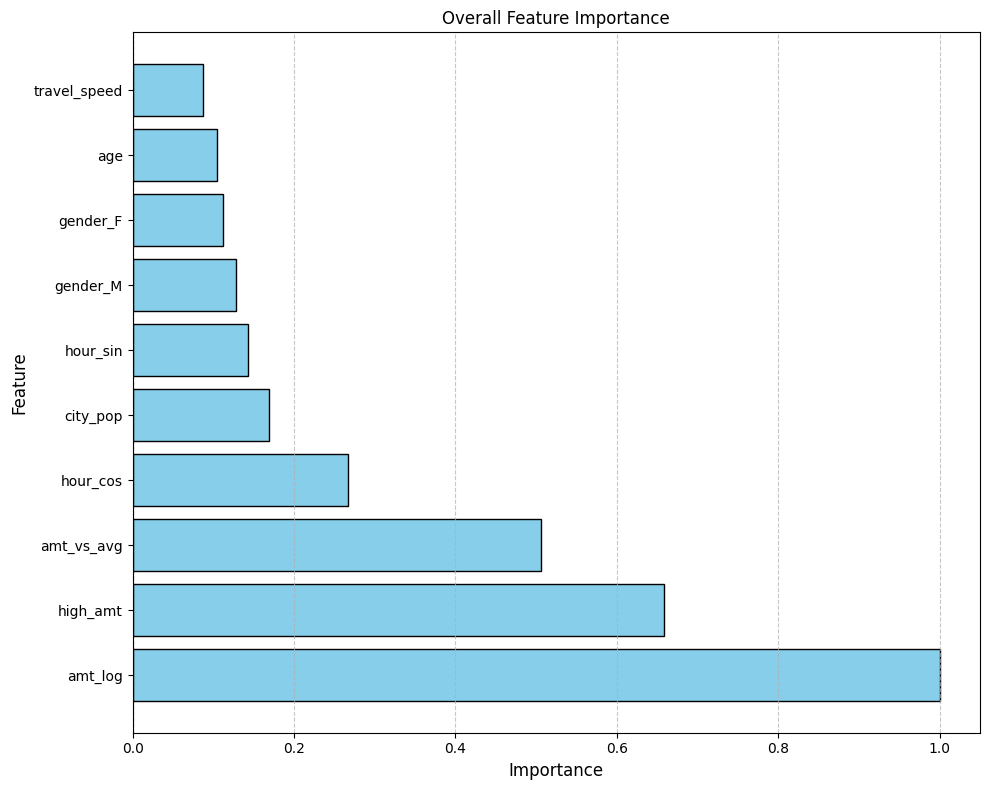

In [ ]:
# Plot the feature importance
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in feature_comparison_df['average_importance']]
plt.barh(feature_comparison_df['feature'], feature_comparison_df['average_importance'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Overall Feature Importance')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Gen AI** narrative on feature importance     
The following codes are commented because the API key can only be accessed locally. However, the Gen AI narrative is captured and shown.

In [ ]:
# Convert dataframe to string format
#data_string = feature_comparison_df.to_string(index=False).replace('\n', ' ')
#data_dict = {"data": data_string}

In [ ]:
# Provide the API key
#import os

#client = Groq(
#    api_key=os.getenv("GROQ_API_KEY")
#)

In [ ]:
# Send the feature importance data for analysis
#chat_completion = client.chat.completions.create(
#    messages=[
#        {"role": "user", "content": f"Analyze the following feature importance data on credit card fraud: {data_dict['data']}"}
#    ],
#    model="llama-3.1-8b-instant",
#)

#narrative = chat_completion.choices[0].message.content
#narrative = narrative.replace('\n', ' ')

In [ ]:
# Obtain the narrative or report from the GenAI model
#from IPython.display import Markdown

#Markdown(narrative)

**Feature Importance Analysis: Credit Card Fraud Detection**  ### Overview  The feature importance data provided contains the average importance values of various features used in a machine learning model to detect credit card fraud. The features are ranked based on their contribution to the model's performance, with higher values indicating greater importance.  ### Key Observations  1. **amt_log** is the most important feature, contributing about 1.0 to the model's performance. This suggests that the log-transformed transaction amount is a key predictor of fraud. 2. **high_amt** is the second most important feature, with an average importance of 0.658. This feature might indicate high-value transactions that are more likely to be fraudulent. 3. The top three features (amt_log, high_amt, and amt_vs_avg) are all related to transaction amounts, suggesting that the model is paying close attention to these factors when predicting fraud. 4. The next group of important features include hour_cos (0.267), hour_sin (0.143), and city_pop (0.169). These features might be used to capture temporal and spatial patterns in transaction behavior that are indicative of fraud.  ### Insights for Model Building  1. **Focus on transaction amount features**: The high importance of amt_log and high_amt suggests that transaction amounts are a strong predictor of fraud. Consider incorporating more features related to transaction amounts, such as transaction value distributions or averages. 2. **Consider temporal patterns**: The presence of hour_cos and hour_sin in the top features indicates that temporal patterns in transactions may be useful for detecting fraud. You could explore additional features that capture temporal dynamics, such as day of the week or time of day. 3. **Look for spatial patterns**: The importance of city_pop suggests that geographic location may be a factor in predicting fraud. Consider incorporating features that capture regional differences in transaction behavior.  ### Code to Extract Insights  You can use the following Python code to extract insights from this feature importance data: ```python import pandas as pd  # Define the feature importance data feature_importance = {     'feature': ['amt_log', 'high_amt', 'amt_vs_avg', 'hour_cos', 'city_pop', 'hour_sin', 'gender_M', 'gender_F', 'age', 'travel_speed'],     'average_importance': [1.0, 0.658, 0.505, 0.267, 0.169, 0.143, 0.128, 0.112, 0.105, 0.088] }  # Create a DataFrame from the feature importance data df = pd.DataFrame(feature_importance)  # Sort the DataFrame by average importance in descending order df = df.sort_values(by='average_importance', ascending=False)  # Print the top 5 features with the highest importance print(df.head(5)) ``` This code will output the top 5 features with the highest importance, which can be used to guide model building and feature engineering efforts.

##Gen AI narrative on feature importance

Feature Importance Analysis: Credit Card Fraud Detection ### Overview The feature importance data provided contains the average importance values of various features used in a machine learning model to detect credit card fraud. The features are ranked based on their contribution to the model's performance, with higher values indicating greater importance. ### Key Observations 1. amt_log is the most important feature, contributing about 1.0 to the model's performance. This suggests that the log-transformed transaction amount is a key predictor of fraud. 2. high_amt is the second most important feature, with an average importance of 0.658. This feature might indicate high-value transactions that are more likely to be fraudulent. 3. The top three features (amt_log, high_amt, and amt_vs_avg) are all related to transaction amounts, suggesting that the model is paying close attention to these factors when predicting fraud. 4. The next group of important features include hour_cos (0.267), hour_sin (0.143), and city_pop (0.169). These features might be used to capture temporal and spatial patterns in transaction behavior that are indicative of fraud. ### Insights for Model Building 1. Focus on transaction amount features: The high importance of amt_log and high_amt suggests that transaction amounts are a strong predictor of fraud. Consider incorporating more features related to transaction amounts, such as transaction value distributions or averages. 2. Consider temporal patterns: The presence of hour_cos and hour_sin in the top features indicates that temporal patterns in transactions may be useful for detecting fraud. You could explore additional features that capture temporal dynamics, such as day of the week or time of day. 3. Look for spatial patterns: The importance of city_pop suggests that geographic location may be a factor in predicting fraud. Consider incorporating features that capture regional differences in transaction behavior. ### Code to Extract Insights You can use the following Python code to extract insights from this feature importance data: python import pandas as pd # Define the feature importance data feature_importance = { 'feature': ['amt_log', 'high_amt', 'amt_vs_avg', 'hour_cos', 'city_pop', 'hour_sin', 'gender_M', 'gender_F', 'age', 'travel_speed'], 'average_importance': [1.0, 0.658, 0.505, 0.267, 0.169, 0.143, 0.128, 0.112, 0.105, 0.088] } # Create a DataFrame from the feature importance data df = pd.DataFrame(feature_importance) # Sort the DataFrame by average importance in descending order df = df.sort_values(by='average_importance', ascending=False) # Print the top 5 features with the highest importance print(df.head(5)) This code will output the top 5 features with the highest importance, which can be used to guide model building and feature engineering efforts.

## OVERALL MODEL SUMMARY  

Based on the metrics of  AUC, Accuracy, Precision, Recall, F2 Score, and Profit/Loss, the **XGBoost Classifier** is the winner.  **Decision Tree Classifier** and **Random Forest Classifier** are virtually tied for the second place.

For this particular dataset, the **XGBoost Classifier**  is the recommended machine learning algorithm.    

The **feature importance** is consistent with what is highlighted in the **Heatmap of Significant Correlations**: `amt_log`, `high_amt`, and  `amt_vs_avg`.


##Next Steps and Further Recommendations    
- Confirm the model that will suit the business needs in terms of the optimal level of fraud identification and precision.    
- Continue model development to include actual identification of fraudulent transactions.
- Tune the thresholds to maximize profit using realistic lifetime value and cost of retention assumptions.
- Deploy and apply the model for the use of relevant business groups tasked with prevention of credit card fraudulent transactions. Leadership can also be guided by the model for fraud prevention strategy.     
- Continue model development to validate the features relative importance to guide management on which features need to be given particular attention in order to prevent fraud.
